In [5]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
url="https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv"
data=pd.read_csv(url)

In [8]:
data.head(10)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [11]:
data.describe().round(2)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00
mean,3.85,120.89,69.11,20.54,79.80,31.99,0.47,33.24,0.35
std,3.37,31.97,19.36,15.95,115.24,7.88,0.33,11.76,0.48
min,0.00,0.00,0.00,0.00,0.00,0.00,0.08,21.00,0.00
25%,1.00,99.00,62.00,0.00,0.00,27.30,0.24,24.00,0.00
50%,3.00,117.00,72.00,23.00,30.50,32.00,0.37,29.00,0.00
75%,6.00,140.25,80.00,32.00,127.25,36.60,0.63,41.00,1.00
max,17.00,199.00,122.00,99.00,846.00,67.10,2.42,81.00,1.00


In [13]:
data.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [15]:
np.mean(data["Glucose"])

120.89453125

In [17]:
np.std(data["BMI"])

7.879025731540125

In [19]:
data["glucose-norm"]=(data["Glucose"]-np.mean(data["Glucose"]))/np.std(data["Glucose"])


In [21]:
data["glucose-norm"]

0      0.848324
1     -1.123396
2      1.943724
3     -0.998208
4      0.504055
         ...   
763   -0.622642
764    0.034598
765    0.003301
766    0.159787
767   -0.873019
Name: glucose-norm, Length: 768, dtype: float64

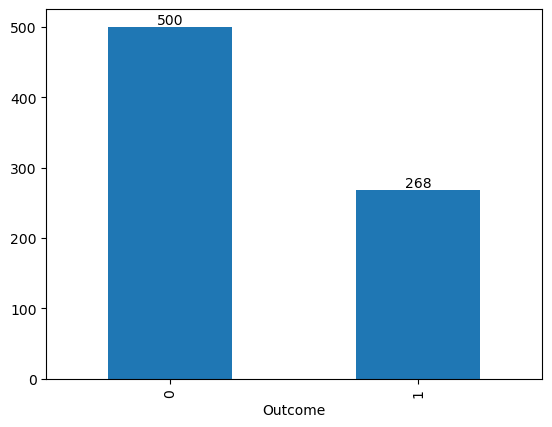

In [27]:
ax=data["Outcome"].value_counts().plot(kind="bar")
for container in ax.containers:
    ax.bar_label(container)
plt.show()

In [11]:
pivot=pd.pivot_table(data,
                     values="Glucose",
                     index="Outcome",
                     aggfunc=["mean","max","std"]
                    )

In [13]:
pivot

,mean,max,std
,Glucose,Glucose,Glucose
Outcome,,,
0,109.980000,197,26.141200
1,141.257463,199,31.939622


In [15]:
BMI_Age=pd.pivot_table(data,
                      values=["BMI","Age"],
                      index="Outcome",
                      aggfunc="mean")

In [17]:
BMI_Age

,Age,BMI
Outcome,,
0,31.190000,30.304200
1,37.067164,35.142537


In [21]:
data["Age_group"]=pd.cut(data["Age"],bins=[20,30,40,50,60,70],
                        labels=["20-30","30-40","40-50","50-60","60-70"])


In [31]:
glu_age=pd.pivot_table(data,values="Glucose",index="Outcome",columns="Age_group",aggfunc="mean",observed=False)

In [35]:
glu_age.round(2)

Age_group,20-30,30-40,40-50,50-60,60-70
Outcome,,,,,
0,106.98,114.15,108.00,124.57,130.67
1,140.32,139.00,137.81,153.45,155.29


In [29]:
data["Age"].describe()

count    768.000000
mean      33.240885
std       11.760232
min       21.000000
25%       24.000000
50%       29.000000
75%       41.000000
max       81.000000
Name: Age, dtype: float64

In [41]:
melted=pd.melt(glu_age.reset_index(),
              id_vars="Outcome",
              var_name="Agegroup",
              value_name="Glucose")

In [43]:
melted

,Outcome,Agegroup,Glucose
0,0,20-30,106.978593
1,1,20-30,140.322222
2,0,30-40,114.148148
3,1,30-40,139.000000
4,0,40-50,108.000000
5,1,40-50,137.812500
6,0,50-60,124.565217
7,1,50-60,153.451613
8,0,60-70,130.666667
9,1,60-70,155.285714


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [15]:
cols=['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
data[cols]=data[cols].replace(0,data[cols].mean())

In [17]:
x=data.drop('Outcome',axis=1)
y=data['Outcome']

In [21]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)


In [31]:
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression(max_iter=2000)
lr.fit(x_train,y_train)

LogisticRegression(max_iter=2000)

In [33]:
y_pred_lr=lr.predict(x_test)
acc_lr=accuracy_score(y_test,y_pred_lr)

In [35]:
acc_lr

0.7662337662337663

In [37]:
y_pred_lr

array([0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0,
       0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0,
       0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1,
       0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1,
       0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
      dtype=int64)

In [39]:
from sklearn.tree import DecisionTreeClassifier
dt=DecisionTreeClassifier()
dt.fit(x_train,y_train)

DecisionTreeClassifier()

In [43]:
y_pred_dt=dt.predict(x_test)
acc_dt=accuracy_score(y_test,y_pred_dt)

In [45]:
acc_dt

0.7272727272727273

In [47]:
from sklearn.ensemble import RandomForestClassifier
rf= RandomForestClassifier()
rf.fit(x_train,y_train)

RandomForestClassifier()

In [49]:
y_pred_rf=rf.predict(x_test)
acc_rf=accuracy_score(y_test,y_pred_rf)

In [51]:
acc_rf

0.7532467532467533

In [59]:
from sklearn.neighbors import KNeighborsClassifier
KN=KNeighborsClassifier()
KN.fit(x_train,y_train)

KNeighborsClassifier()

In [61]:
y_pred_KN=KN.predict(x_test)
acc_KN=accuracy_score(y_test,y_pred_KN)

In [63]:
acc_KN

0.6753246753246753

In [65]:
Results=pd.DataFrame({'Model':['Logistic Regression','Decision Tree','Random Forest','KNN',],'Accuracy_score':[acc_lr,acc_dt,acc_rf,acc_KN]})

In [73]:
Results.sort_index(ascending=True)

,Model,Accuracy_score
0,Logistic Regression,0.766234
1,Decision Tree,0.727273
2,Random Forest,0.753247
3,KNN,0.675325


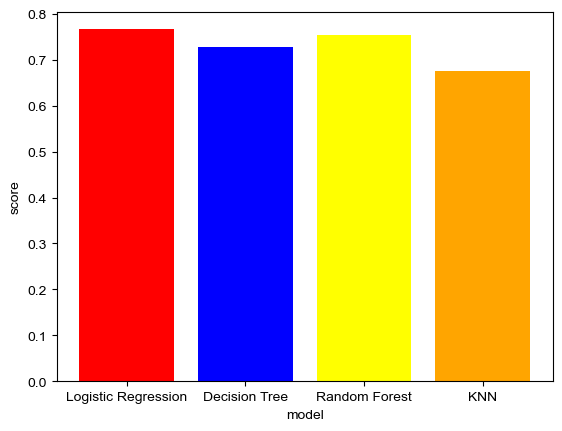

In [97]:
colors=('red','blue','yellow','orange')
ax=plt.bar(Results['Model'],Results['Accuracy_score'],color=colors)
plt.xlabel("model",fontname="Arial")
plt.ylabel("score",fontname="Arial")
plt.xticks(fontname="Arial")
plt.yticks(fontname="Arial")
plt.show()